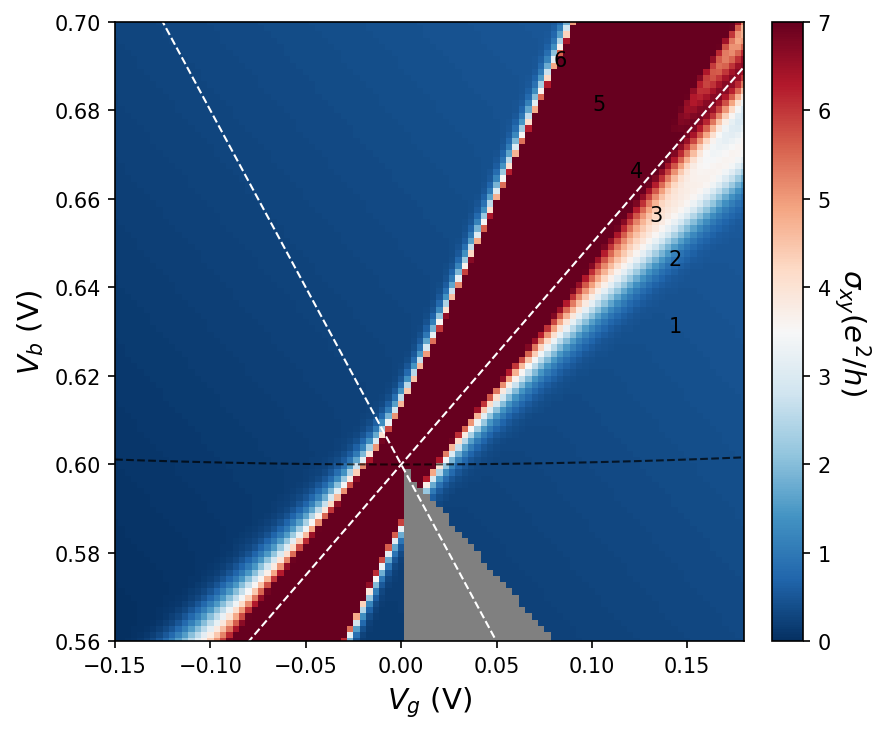

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
# Grid for Vg (Gate Voltage) and Vb (Bias Voltage)
Vg = np.linspace(-0.15, 0.18, 100)
Vb = np.linspace(0.56, 0.70, 100)
X, Y = np.meshgrid(Vg, Vb)

# Simulate Landau Levels / Fan Diagram
# Sigma_xy roughly proportional to filling factor nu
# Pattern radiates from a point (likely origin or offset)
def landau_fan(vg, vb, n):
    # Slope depends on n (filling factor integer)
    slope = 0.3 + 0.1 * n
    # Distance from the line y = slope * x + intercept
    dist = (vb - (slope * vg + 0.60)) 
    # Create a "plateau" width
    return np.exp(- (dist / 0.008)**2) * n

# Summing multiple levels
Z = np.zeros_like(X)
for n in range(1, 8):
    Z += landau_fan(X, Y, n)

# Add background gradient (red to blue)
Z_bg = (Y - 0.56) * 10 + (X + 0.15) * 5
# Combine: Steps + Gradient
Z_final = Z * 3 + Z_bg * 0.2

# Masking lower right corner (Gray region)
mask = (Y < (-0.5 * X + 0.60)) & (X > 0)
Z_masked = np.ma.masked_where(mask, Z_final)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Heatmap
# RdBu_r is Red-White-Blue reversed (Blue=Low, Red=High)
cmap = plt.cm.RdBu_r
mesh = ax.pcolormesh(X, Y, Z_masked, cmap=cmap, shading='auto', vmin=0, vmax=7)

# Colorbar
cbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\sigma_{xy} (e^2/h)$', fontsize=14, rotation=270, labelpad=20)
cbar.set_ticks(range(8))

# Overlay Dashed Lines (Fan edges)
x_line = np.linspace(-0.15, 0.18, 50)
y_curve = 0.05 * x_line**2 + 0.60  # Parabolic boundary
ax.plot(x_line, y_curve, 'k--', linewidth=1, alpha=0.7)

# White dashed lines radiating from roughly (0, 0.60)
for slope in [0.5, -0.8]:
    ax.plot(x_line, slope * x_line + 0.60, 'w--', linewidth=1)

# Numbers (Filling factors)
ax.text(0.14, 0.63, '1', fontsize=10)
ax.text(0.14, 0.645, '2', fontsize=10)
ax.text(0.13, 0.655, '3', fontsize=10)
ax.text(0.12, 0.665, '4', fontsize=10)
ax.text(0.10, 0.68, '5', fontsize=10)
ax.text(0.08, 0.69, '6', fontsize=10)

# Labels
ax.set_xlabel(r'$V_g$ (V)', fontsize=14)
ax.set_ylabel(r'$V_b$ (V)', fontsize=14)
ax.set_ylim(0.56, 0.70)
ax.set_xlim(-0.15, 0.18)

# Gray patch for masked area
# Since pcolormesh handles masking by not drawing, we manually add gray background if needed
# But matplotlib shows white for masked. Let's add a gray polygon behind.
ax.set_facecolor('gray') 

plt.tight_layout()
plt.show()
